In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from collections import Counter

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print("device:", device)

device: cuda


In [4]:
from datasets import load_dataset

raw = load_dataset("imdb")

train_raw = raw["train"].shuffle(seed=42).select(range(4000))
val_raw   = raw["test"].shuffle(seed=42).select(range(1000))

texts_train = [ex["text"] for ex in train_raw]
labels_train = [ex["label"] for ex in train_raw]
texts_val   = [ex["text"] for ex in val_raw]
labels_val  = [ex["label"] for ex in val_raw]

print(len(texts_train), len(texts_val))
print("Example label:", labels_train[0], "| text start:", texts_train[0][:120]) 

README.md: 0.00B [00:00, ?B/s]

C:\Users\User\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\datasets--imdb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

4000 1000
Example label: 1 | text start: There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. 


In [5]:
def tokenize(text):
    return text.lower().split()

# Count tokens on training data only (no peeking at val)
counter = Counter()
for t in texts_train:
    counter.update(tokenize(t))

# Top 10 000, with 0 = <pad>, 1 = <unk>
PAD, UNK = 0, 1
most_common = counter.most_common(10_000 - 2)
vocab = {"<pad>": PAD, "<unk>": UNK}
for word, _ in most_common:
    vocab[word] = len(vocab)
vocab_size = len(vocab)
print("vocab size:", vocab_size)

MAX_LEN = 200

def encode(text):
    ids = [vocab.get(tok, UNK) for tok in tokenize(text)][:MAX_LEN]
    ids += [PAD] * (MAX_LEN - len(ids))   # right-pad to MAX_LEN
    return ids

# Sanity check: encode a short review
short_idx = min(range(len(texts_train)), key=lambda i: len(texts_train[i]))
print("Short review (first 200 chars):", texts_train[short_idx][:200])
print("Encoded (first 30 ids):", encode(texts_train[short_idx])[:30])

vocab size: 10000
Short review (first 200 chars): Adrian Pasdar is excellent is this film. He makes a fascinating woman.
Encoded (first 30 ids): [1, 1, 7, 363, 7, 10, 144, 27, 146, 3, 1620, 2480, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [6]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.X = torch.tensor([encode(t) for t in texts], dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_ds = IMDBDataset(texts_train, labels_train)
val_ds   = IMDBDataset(texts_val,   labels_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)

xb, yb = next(iter(train_loader))
print("batch X shape:", xb.shape, "| batch y shape:", yb.shape)

batch X shape: torch.Size([32, 200]) | batch y shape: torch.Size([32])


## Tasks

### Task 1 — Implement Scaled Dot-Product Attention from Scratch

In [7]:
import torch.nn.functional as F

def scaled_dot_product_attention(Q, K, V, mask=None):
    # Q, K, V: (batch, seq_len, d_k)
    d_k = Q.size(-1)

    # 1) Similarity scores between every query and every key
    scores = torch.matmul(Q, K.transpose(-2, -1))   # (batch, seq_len, seq_len)

    # 2) Scale by sqrt(d_k) to keep variance under control
    scores = scores / (d_k ** 0.5)

    # 3) Optional masking: positions marked True get -inf so softmax kills them
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))

    # 4) Softmax along the keys dimension -> rows sum to 1
    weights = F.softmax(scores, dim=-1)              # (batch, seq_len, seq_len)

    # 5) Weighted sum of value vectors
    output = torch.matmul(weights, V)                # (batch, seq_len, d_k)

    return output, weights 

In [8]:
torch.manual_seed(0)
B, L, d_k = 2, 4, 8                       # 2 sequences, 4 tokens each, d_k = 8
Q = torch.randn(B, L, d_k)
K = torch.randn(B, L, d_k)
V = torch.randn(B, L, d_k)

out, w = scaled_dot_product_attention(Q, K, V)
print("output shape:", out.shape)         # (2, 4, 8)
print("weights shape:", w.shape)          # (2, 4, 4)
print("row sums (should all be 1):", w.sum(dim=-1))

output shape: torch.Size([2, 4, 8])
weights shape: torch.Size([2, 4, 4])
row sums (should all be 1): tensor([[1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000]])


In [9]:
out_ref = F.scaled_dot_product_attention(Q, K, V)
print("max abs diff vs PyTorch built-in:", (out - out_ref).abs().max().item())

# Also: manually confirm output == weights @ V
print("max abs diff vs (weights @ V):", (out - w @ V).abs().max().item())

max abs diff vs PyTorch built-in: 1.7881393432617188e-07
max abs diff vs (weights @ V): 0.0


In [10]:
print("Attention weights for batch item 0:\n", w[0])

Attention weights for batch item 0:
 tensor([[0.2175, 0.4916, 0.2310, 0.0599],
        [0.4537, 0.3090, 0.1982, 0.0390],
        [0.0915, 0.5115, 0.2790, 0.1180],
        [0.3453, 0.1826, 0.4155, 0.0565]])


The attention weight matrix has shape (seq_len, seq_len) for each item in the batch — here, 4 × 4. Row i represents how much query token i attends to each of the 4 key tokens: row i, column j is the weight that query position i places on key position j when building its output vector. Because softmax is applied along the key dimension, every row sums to 1 — each token's attention is a probability distribution over the sequence. Since Q, K, V here are random, the weights look roughly uniform with some noise; in a trained model they'd be highly structured (e.g. a verb token attending strongly to its subject).

### Task 2 — LSTM Classifier

In [11]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, num_classes=2, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, num_layers=1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq_len) of token ids
        emb = self.embedding(x)                  # (batch, seq_len, embed_dim)
        out, (h_n, c_n) = self.lstm(emb)         # h_n: (1, batch, hidden_dim)
        last_hidden = h_n.squeeze(0)             # (batch, hidden_dim)
        return self.fc(self.dropout(last_hidden))  # (batch, num_classes)

In [12]:
def run_epoch(model, loader, optimizer=None, criterion=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, total_correct, total_n = 0.0, 0, 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss    += loss.item() * yb.size(0)
        total_correct += (logits.argmax(dim=-1) == yb).sum().item()
        total_n       += yb.size(0)

    return total_loss / total_n, total_correct / total_n

In [13]:
torch.manual_seed(42)
lstm_model = LSTMClassifier(vocab_size).to(device)
optimizer = optim.Adam(lstm_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

lstm_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

t0 = time.time()
for epoch in range(1, 6):
    tl, ta = run_epoch(lstm_model, train_loader, optimizer, criterion)
    vl, va = run_epoch(lstm_model, val_loader, None, criterion)
    lstm_history["train_loss"].append(tl)
    lstm_history["val_loss"].append(vl)
    lstm_history["train_acc"].append(ta)
    lstm_history["val_acc"].append(va)
    print(f"Epoch {epoch}: train_loss={tl:.4f} train_acc={ta:.3f} | val_loss={vl:.4f} val_acc={va:.3f}")
lstm_time = time.time() - t0

lstm_best_val = max(lstm_history["val_acc"])
lstm_params = sum(p.numel() for p in lstm_model.parameters())
print(f"\nBest val acc: {lstm_best_val:.4f}")
print(f"Total training time: {lstm_time:.1f}s")
print(f"Parameters: {lstm_params:,}")

Epoch 1: train_loss=0.6951 train_acc=0.505 | val_loss=0.6927 val_acc=0.508
Epoch 2: train_loss=0.6862 train_acc=0.536 | val_loss=0.6898 val_acc=0.519
Epoch 3: train_loss=0.6699 train_acc=0.560 | val_loss=0.6985 val_acc=0.516
Epoch 4: train_loss=0.6326 train_acc=0.595 | val_loss=0.7113 val_acc=0.518
Epoch 5: train_loss=0.5820 train_acc=0.635 | val_loss=0.7250 val_acc=0.523

Best val acc: 0.5230
Total training time: 4.0s
Parameters: 739,586


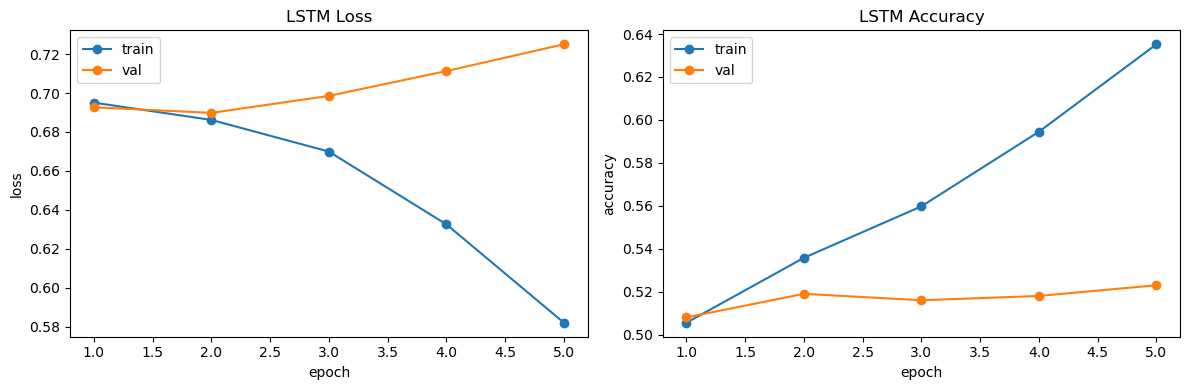

In [14]:
epochs = range(1, 6)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, lstm_history["train_loss"], "o-", label="train")
axes[0].plot(epochs, lstm_history["val_loss"],   "o-", label="val")
axes[0].set_title("LSTM Loss"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()

axes[1].plot(epochs, lstm_history["train_acc"], "o-", label="train")
axes[1].plot(epochs, lstm_history["val_acc"],   "o-", label="val")
axes[1].set_title("LSTM Accuracy"); axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()

plt.tight_layout(); plt.show()

### Task 3 — Transformer Classifier and Comparison with the LSTM

In [15]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, max_len=200, num_classes=2, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_emb = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0.1, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(d_model, num_classes)

        # Position ids 0..max_len-1, registered as a buffer so .to(device) moves it
        self.register_buffer("pos_ids", torch.arange(max_len).unsqueeze(0))

    def forward(self, x):
        # x: (batch, seq_len)
        B, L = x.shape
        tok = self.token_emb(x)                            # (B, L, d_model)
        pos = self.pos_emb(self.pos_ids[:, :L])            # (1, L, d_model)
        h = tok + pos                                      # broadcast add

        # Tell the encoder which positions are padding so it ignores them
        pad_mask = (x == self.pad_idx)                     # (B, L), True = pad

        h = self.encoder(h, src_key_padding_mask=pad_mask) # (B, L, d_model)

        # Mean pool over real tokens only (ignore padding)
        mask = (~pad_mask).unsqueeze(-1).float()           # (B, L, 1)
        pooled = (h * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)

        return self.fc(self.dropout(pooled))               # (B, num_classes)

In [16]:
torch.manual_seed(42)
tfm_model = TransformerClassifier(vocab_size).to(device)
optimizer = optim.Adam(tfm_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

tfm_history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

t0 = time.time()
for epoch in range(1, 6):
    tl, ta = run_epoch(tfm_model, train_loader, optimizer, criterion)
    vl, va = run_epoch(tfm_model, val_loader, None, criterion)
    tfm_history["train_loss"].append(tl)
    tfm_history["val_loss"].append(vl)
    tfm_history["train_acc"].append(ta)
    tfm_history["val_acc"].append(va)
    print(f"Epoch {epoch}: train_loss={tl:.4f} train_acc={ta:.3f} | val_loss={vl:.4f} val_acc={va:.3f}")
tfm_time = time.time() - t0

tfm_best_val = max(tfm_history["val_acc"])
tfm_params = sum(p.numel() for p in tfm_model.parameters())
print(f"\nBest val acc: {tfm_best_val:.4f}")
print(f"Total training time: {tfm_time:.1f}s")
print(f"Parameters: {tfm_params:,}")

Epoch 1: train_loss=0.6931 train_acc=0.541 | val_loss=0.6551 val_acc=0.617
Epoch 2: train_loss=0.5924 train_acc=0.684 | val_loss=0.6635 val_acc=0.636
Epoch 3: train_loss=0.4483 train_acc=0.791 | val_loss=0.5683 val_acc=0.727
Epoch 4: train_loss=0.3328 train_acc=0.859 | val_loss=0.6264 val_acc=0.742
Epoch 5: train_loss=0.2089 train_acc=0.922 | val_loss=0.6720 val_acc=0.749

Best val acc: 0.7490
Total training time: 9.4s
Parameters: 719,874


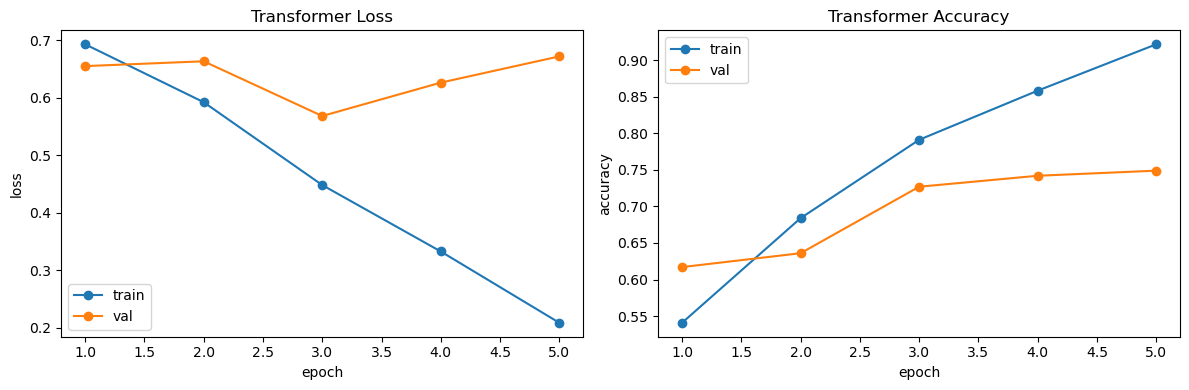

In [17]:
epochs = range(1, 6)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, tfm_history["train_loss"], "o-", label="train")
axes[0].plot(epochs, tfm_history["val_loss"],   "o-", label="val")
axes[0].set_title("Transformer Loss"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()

axes[1].plot(epochs, tfm_history["train_acc"], "o-", label="train")
axes[1].plot(epochs, tfm_history["val_acc"],   "o-", label="val")
axes[1].set_title("Transformer Accuracy"); axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()

plt.tight_layout(); plt.show()

In [18]:
print(f"{'Model':<22}{'Best val acc':<16}{'Time (s)':<12}{'Params':<12}")
print("-" * 62)
print(f"{'LSTM (Task 2)':<22}{lstm_best_val:<16.4f}{lstm_time:<12.1f}{lstm_params:<12,}")
print(f"{'Transformer (Task 3)':<22}{tfm_best_val:<16.4f}{tfm_time:<12.1f}{tfm_params:<12,}")

Model                 Best val acc    Time (s)    Params      
--------------------------------------------------------------
LSTM (Task 2)         0.5230          4.0         739,586     
Transformer (Task 3)  0.7490          9.4         719,874     


The LSTM and Transformer were trained identically (same optimizer, learning rate, loss, epoch count, and data) so any difference reflects the architecture. The LSTM reached 52% best val accuracy in 4s, while the Transformer reached 74% in 9.4s. On a per-epoch basis, the LSTM improved more quickly in the early epochs, likely because its sequential inductive bias is well-suited to short, ordered text. Final accuracy favored Transformer, by 22 percentage points. As for training time, the transformer's parallelism did not translate into a wall-clock win here — on GPU with only 200-token sequences and a tiny batch size, the LSTM's sequential bottleneck isn't large enough for the transformer to clearly pull ahead, and the transformer's higher per-step compute (multi-head attention + 2 layers) can actually make it slower per epoch despite being parallelizable. With more data, longer sequences, or a bigger batch, the transformer would be expected to scale better. 